In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import joblib

# 1. Load Data
df = pd.read_csv('yield_df.csv')

In [30]:
# 1a. Filter for African Countries ONLY
african_countries = [
    'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi',
    'Cameroon', 'Central African Republic', 'Chad', 'Comoros',
    'Congo', 'Democratic Republic of the Congo', 'Djibouti', 'Egypt',
    'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon',
    'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho',
    'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania',
    'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria',
    'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles',
    'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan',
    'United Republic of Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'
]
df_africa = df[df['Area'].isin(african_countries)]

# 1b. Data Cleaning (Notice we are keeping 'Area' this time!)
columns_to_drop = ['Unnamed: 0', 'Item', 'Year']
df_cleaned = df_africa.drop(columns=columns_to_drop)

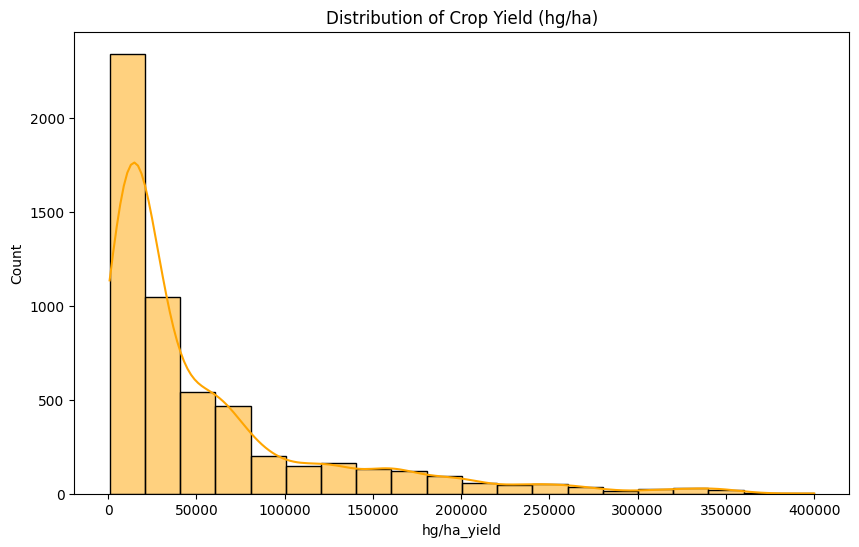

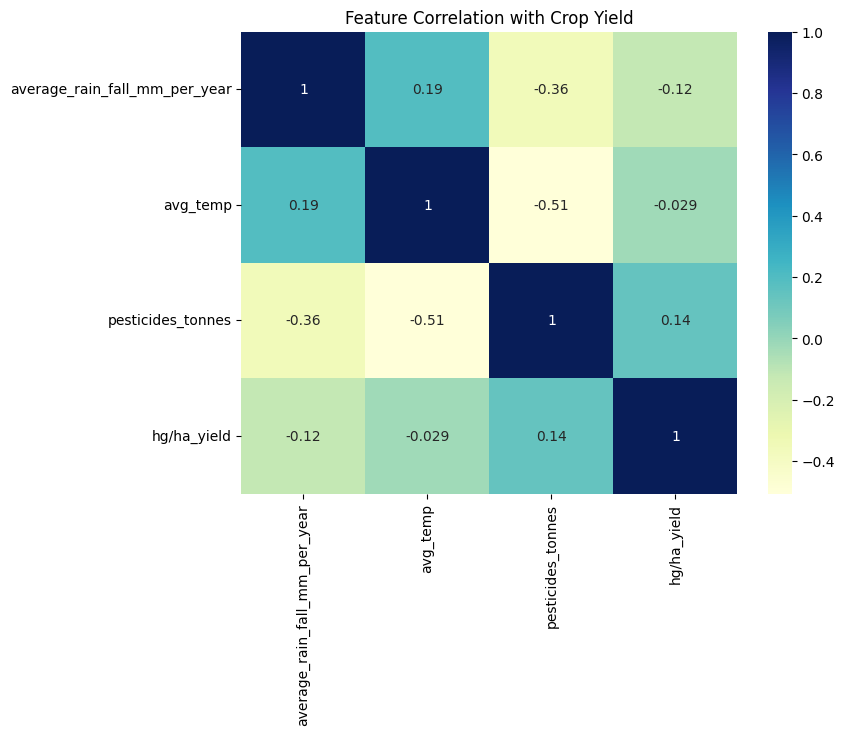

In [31]:
# 2. Visualizations (Required by Rubric - MUST BE DONE BEFORE ENCODING)
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['hg/ha_yield'], bins=20, kde=True, color='orange')
plt.title('Distribution of Crop Yield (hg/ha)')
plt.show()

# Only correlate the numeric columns for the heatmap
numeric_cols = ['average_rain_fall_mm_per_year', 'avg_temp', 'pesticides_tonnes', 'hg/ha_yield']
plt.figure(figsize=(8, 6))
sns.heatmap(df_cleaned[numeric_cols].corr(), annot=True, cmap='YlGnBu')
plt.title('Feature Correlation with Crop Yield')
plt.show()

In [32]:
# 3. Feature Engineering: One-Hot Encoding the Country
# This turns the 'Area' column into multiple numeric columns (Area_Rwanda, Area_Kenya, etc.)
df_encoded = pd.get_dummies(df_cleaned, columns=['Area'])

# Separate Features (X) and Target (y)
X = df_encoded.drop(columns=['hg/ha_yield'])
y = df_encoded['hg/ha_yield']

# CRITICAL: Save the column names so the API knows how to format the data later
model_columns = list(X.columns)
joblib.dump(model_columns, 'model_columns.pkl')

['model_columns.pkl']

In [33]:
# 4. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for the API
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [34]:
# 5. Model Training & Comparison
models = {
    "Stochastic Gradient Descent": SGDRegressor(max_iter=1000, tol=1e-3, random_state=42),
    "Standard Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42)
}

best_model = None
lowest_mse = float('inf')

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, preds)
    print(f"{name} MSE: {mse:.4f}")
    if mse < lowest_mse:
        lowest_mse = mse
        best_model = model

# Save the best model
joblib.dump(best_model, 'best_model.pkl')
print(f"\nBest Model Saved: {best_model}")

Stochastic Gradient Descent MSE: 3942628429.0315
Standard Linear Regression MSE: 3932097645.5733
Random Forest MSE: 5397390447.0342
Decision Tree MSE: 5510025247.6117

Best Model Saved: LinearRegression()


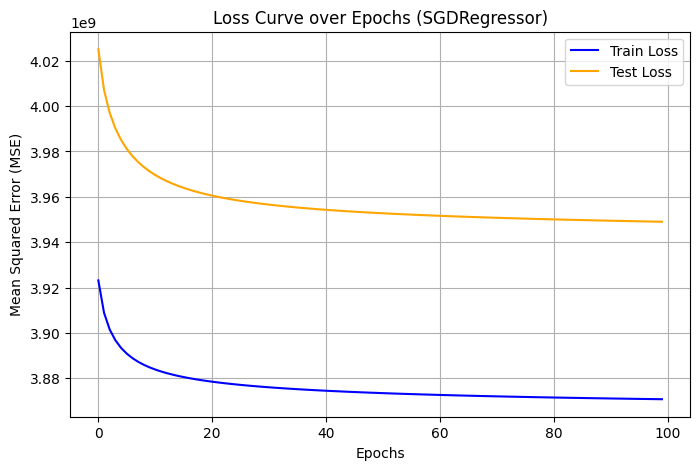

In [35]:
# 6. Plot Loss Curve for Test and Train Data (Rubric Requirement)
sgd_model = SGDRegressor(random_state=42)
train_losses = []
test_losses = []

epochs = 100
for epoch in range(epochs):
    sgd_model.partial_fit(X_train_scaled, y_train)
    train_pred = sgd_model.predict(X_train_scaled)
    test_pred = sgd_model.predict(X_test_scaled)
    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

plt.figure(figsize=(8, 5))
plt.plot(range(epochs), train_losses, label='Train Loss', color='blue')
plt.plot(range(epochs), test_losses, label='Test Loss', color='orange')
plt.title('Loss Curve over Epochs (SGDRegressor)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

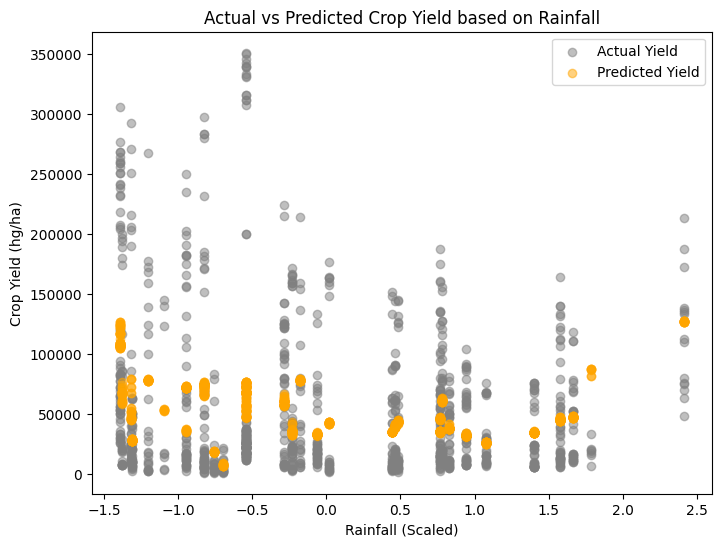

In [36]:
# 7. Scatter Plot of Before & After (Rubric Requirement)
feature_idx = 0 # Plotting against Rainfall
plt.figure(figsize=(8, 6))
plt.scatter(X_test_scaled[:, feature_idx], y_test, color='gray', label='Actual Yield', alpha=0.5)
plt.scatter(X_test_scaled[:, feature_idx], best_model.predict(X_test_scaled), color='orange', label='Predicted Yield', alpha=0.5)
plt.title('Actual vs Predicted Crop Yield based on Rainfall')
plt.xlabel('Rainfall (Scaled)')
plt.ylabel('Crop Yield (hg/ha)')
plt.legend()
plt.show()

In [37]:
# 8. Single Data Point Prediction (Rubric Requirement)
single_data = X_test_scaled[0].reshape(1, -1)
actual = y_test.iloc[0]
predicted = best_model.predict(single_data)[0]

print("\n--- Single Farm Prediction ---")
print(f"Actual Yield: {actual} hg/ha | Predicted Yield: {predicted:.2f} hg/ha")


--- Single Farm Prediction ---
Actual Yield: 127560 hg/ha | Predicted Yield: 61112.21 hg/ha


In [38]:
# 7. Single Data Point Prediction (Rubric Requirement)
single_data = X_test_scaled[0].reshape(1, -1)
actual = y_test.iloc[0]
predicted = best_model.predict(single_data)[0]

print("\n--- Single Farm Prediction ---")
print(f"Actual Yield: {actual} hg/ha | Predicted Yield: {predicted:.2f} hg/ha")


--- Single Farm Prediction ---
Actual Yield: 127560 hg/ha | Predicted Yield: 61112.21 hg/ha
